In [5]:
import numpy as np
import pandas as pd

In [6]:
columns=['engine_id','cycle']+[f'setting_{i}' for i in range(1,4)]+[f'sensors_{i}' for i in range(1,22)]
df = pd.read_csv('train_FD001.txt', sep='\s+', header=None, names=columns)
print(df.shape)
print (df.head(9))
print(df.dtypes)

(20631, 26)
   engine_id  cycle  setting_1  setting_2  setting_3  sensors_1  sensors_2  \
0          1      1    -0.0007    -0.0004      100.0     518.67     641.82   
1          1      2     0.0019    -0.0003      100.0     518.67     642.15   
2          1      3    -0.0043     0.0003      100.0     518.67     642.35   
3          1      4     0.0007     0.0000      100.0     518.67     642.35   
4          1      5    -0.0019    -0.0002      100.0     518.67     642.37   
5          1      6    -0.0043    -0.0001      100.0     518.67     642.10   
6          1      7     0.0010     0.0001      100.0     518.67     642.48   
7          1      8    -0.0034     0.0003      100.0     518.67     642.56   
8          1      9     0.0008     0.0001      100.0     518.67     642.12   

   sensors_3  sensors_4  sensors_5  ...  sensors_12  sensors_13  sensors_14  \
0    1589.70    1400.60      14.62  ...      521.66     2388.02     8138.62   
1    1591.82    1403.14      14.62  ...      522.

<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
/var/folders/4c/k3416y755cb_jrm7g_zqk1gw0000gn/T/ipykernel_42942/1094230403.py:2: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv('train_FD001.txt', sep='\s+', header=None, names=columns)


In [7]:
max_cycle = df.groupby("engine_id")["cycle"].max()
max_cycle.head(2)

engine_id
1    192
2    287
Name: cycle, dtype: int64

In [8]:
df['max_cycle'] = df['engine_id'].map(max_cycle)
df['RUL']=df['max_cycle']-df['cycle']
df.head(1)
df['label'] = (df['RUL'] <= 0.3*df['max_cycle']).astype(int)
print(df[['engine_id', 'cycle', 'max_cycle', 'RUL', 'label']].head(1))
print(df['label'].value_counts())
df.groupby('label')['label'].count()

   engine_id  cycle  max_cycle  RUL  label
0          1      1        192  191      0
label
0    14387
1     6244
Name: count, dtype: int64


label
0    14387
1     6244
Name: label, dtype: int64

In [9]:
print(df.describe().T[['mean', 'std']].sort_values('std'))
low_variance = df.describe().T['std'][df.describe().T['std'] < 0.01].index
print(low_variance)

                   mean           std
setting_3    100.000000  0.000000e+00
sensors_19   100.000000  0.000000e+00
sensors_18  2388.000000  0.000000e+00
sensors_16     0.030000  1.556432e-14
sensors_10     1.300000  4.660829e-13
sensors_5     14.620000  3.394700e-12
sensors_1    518.670000  6.537152e-11
setting_2      0.000002  2.930621e-04
sensors_6     21.609803  1.388985e-03
setting_1     -0.000009  2.187313e-03
sensors_15     8.442146  3.750504e-02
sensors_8   2388.096652  7.098548e-02
sensors_13  2388.096152  7.191892e-02
sensors_21    23.289705  1.082509e-01
sensors_20    38.816271  1.807464e-01
sensors_11    47.541168  2.670874e-01
label          0.302651  4.594167e-01
sensors_2    642.680934  5.000533e-01
sensors_12   521.413470  7.375534e-01
sensors_7    553.367711  8.850923e-01
sensors_17   393.210654  1.548763e+00
sensors_3   1590.523119  6.131150e+00
sensors_4   1408.933782  9.000605e+00
sensors_14  8143.752722  1.907618e+01
sensors_9   9065.242941  2.208288e+01
engine_id   

In [10]:
df = df.drop(columns=low_variance)
print(df.shape)
print(df.columns.tolist())



(20631, 19)
['engine_id', 'cycle', 'sensors_2', 'sensors_3', 'sensors_4', 'sensors_7', 'sensors_8', 'sensors_9', 'sensors_11', 'sensors_12', 'sensors_13', 'sensors_14', 'sensors_15', 'sensors_17', 'sensors_20', 'sensors_21', 'max_cycle', 'RUL', 'label']


In [11]:
drop_meta = ['engine_id', 'max_cycle', 'RUL']

X = df.drop(columns=drop_meta + ['label'])
y = df['label']

print(X.shape)
print(y.value_counts())


(20631, 15)
label
0    14387
1     6244
Name: count, dtype: int64


In [12]:
print(df.columns.tolist())
print(X.columns.tolist())

['engine_id', 'cycle', 'sensors_2', 'sensors_3', 'sensors_4', 'sensors_7', 'sensors_8', 'sensors_9', 'sensors_11', 'sensors_12', 'sensors_13', 'sensors_14', 'sensors_15', 'sensors_17', 'sensors_20', 'sensors_21', 'max_cycle', 'RUL', 'label']
['cycle', 'sensors_2', 'sensors_3', 'sensors_4', 'sensors_7', 'sensors_8', 'sensors_9', 'sensors_11', 'sensors_12', 'sensors_13', 'sensors_14', 'sensors_15', 'sensors_17', 'sensors_20', 'sensors_21']


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape)

(16504, 15) (4127, 15)


In [14]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [15]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.97      0.96      2911
           1       0.93      0.88      0.90      1216

    accuracy                           0.94      4127
   macro avg       0.94      0.92      0.93      4127
weighted avg       0.94      0.94      0.94      4127



In [16]:
df_test = pd.read_csv('test_FD001.txt', sep=r'\s+', header=None, names=columns)
print(df_test.shape)
rul = pd.read_csv('RUL_FD001.txt', header=None, names=['RUL'])
print(rul.shape)
print(rul.head())

(13096, 26)
(100, 1)
   RUL
0  112
1   98
2   69
3   82
4   91


In [17]:
df_last = df_test.groupby('engine_id').last().reset_index()
print(df_last.shape)

(100, 26)


In [18]:
df_last['RUL'] = rul['RUL'].values
print(df_last[['engine_id', 'RUL']].head())

   engine_id  RUL
0          1  112
1          2   98
2          3   69
3          4   82
4          5   91


In [19]:
df_last['max_cycle'] = df_last['cycle'] + df_last['RUL']
df_last['label'] = (df_last['RUL'] <= 0.3 * df_last['max_cycle']).astype(int)
print(df_last['label'].value_counts())

label
0    61
1    39
Name: count, dtype: int64


In [20]:
X_test_final = df_last[X.columns]
y_test_final = df_last['label']

y_pred_final = model.predict(X_test_final)

from sklearn.metrics import classification_report
print(classification_report(y_test_final, y_pred_final))

              precision    recall  f1-score   support

           0       0.95      0.93      0.94        61
           1       0.90      0.92      0.91        39

    accuracy                           0.93       100
   macro avg       0.93      0.93      0.93       100
weighted avg       0.93      0.93      0.93       100



In [21]:
healthy = df[df['label'] == 0]
sensor_cols = X.columns.tolist()

sensor_mean = healthy[sensor_cols].mean()
sensor_std = healthy[sensor_cols].std()

print(sensor_mean)

cycle           76.067491
sensors_2      642.481960
sensors_3     1588.147319
sensors_4     1404.911419
sensors_7      553.750920
sensors_8     2388.071091
sensors_9     9058.876333
sensors_11      47.419174
sensors_12     521.739360
sensors_13    2388.070332
sensors_14    8139.277733
sensors_15       8.426096
sensors_17     392.586849
sensors_20      38.891556
sensors_21      23.334908
dtype: float64


In [22]:
z_scores = (df[sensor_cols] - sensor_mean) / sensor_std
print(z_scores.head())

      cycle  sensors_2  sensors_3  sensors_4  sensors_7  sensors_8  sensors_9  \
0 -1.560538  -1.720522   0.325753  -0.688461   0.956104  -0.201251  -1.309481   
1 -1.539750  -0.862808   0.770530  -0.282866  -0.001444  -0.564152  -1.528307   
2 -1.518961  -0.342982  -0.033006  -0.113602   0.799129   0.161649  -0.612747   
3 -1.498173  -0.342982  -1.123968  -0.485663   1.097382   0.706000  -0.969888   
4 -1.477384  -0.290999  -1.111380   0.208958   0.390994  -0.201251  -0.384631   

   sensors_11  sensors_12  sensors_13  sensors_14  sensors_15  sensors_17  \
0    0.279412   -0.153170    -0.90135   -0.073704   -0.242101   -0.499968   
1    0.389360    1.043472    -0.00595   -0.872676    0.209366   -0.499968   
2   -0.820063    1.313681    -0.72227   -0.677695   -0.304499   -2.203874   
3   -1.589696    2.162911     0.17313   -0.610460   -2.125051   -0.499968   
4   -0.765089    0.869766    -0.54319   -0.613822    0.121275    0.351985   

   sensors_20  sensors_21  
0    1.249359    1.044

In [23]:
anomalies = (z_scores.abs() > 3)
df['anomaly_count'] = anomalies.sum(axis=1)
print(df['anomaly_count'].value_counts().sort_index())

anomaly_count
0     15856
1      1290
2      1045
3       537
4       339
5       280
6       287
7       247
8       237
9       235
10      152
11       85
12       31
13        9
14        1
Name: count, dtype: int64


In [24]:
anomaly_freq = anomalies.sum().sort_values(ascending=False)
print(anomaly_freq)

sensors_9     2067
sensors_14    1893
sensors_11    1704
sensors_4     1503
sensors_12    1426
cycle         1275
sensors_7     1236
sensors_15    1209
sensors_21    1047
sensors_20     981
sensors_2      851
sensors_13     832
sensors_8      814
sensors_3      782
sensors_17     547
dtype: int64


In [25]:
print(df.groupby('label')['anomaly_count'].mean())

label
0    0.026760
1    2.847854
Name: anomaly_count, dtype: float64


In [26]:
importance = pd.Series(model.feature_importances_, index=X.columns)
print(importance.sort_values(ascending=False))

cycle         0.215206
sensors_11    0.124271
sensors_4     0.106362
sensors_12    0.101215
sensors_7     0.085846
sensors_9     0.065813
sensors_15    0.060660
sensors_14    0.056186
sensors_20    0.048636
sensors_21    0.042754
sensors_2     0.028571
sensors_3     0.018123
sensors_17    0.016638
sensors_8     0.014923
sensors_13    0.014796
dtype: float64


In [27]:
print(df.groupby('engine_id')['cycle'].max().sort_values(ascending=False).head(10))

engine_id
69    362
92    341
96    336
67    313
83    293
2     287
95    283
64    283
86    278
17    276
Name: cycle, dtype: int64


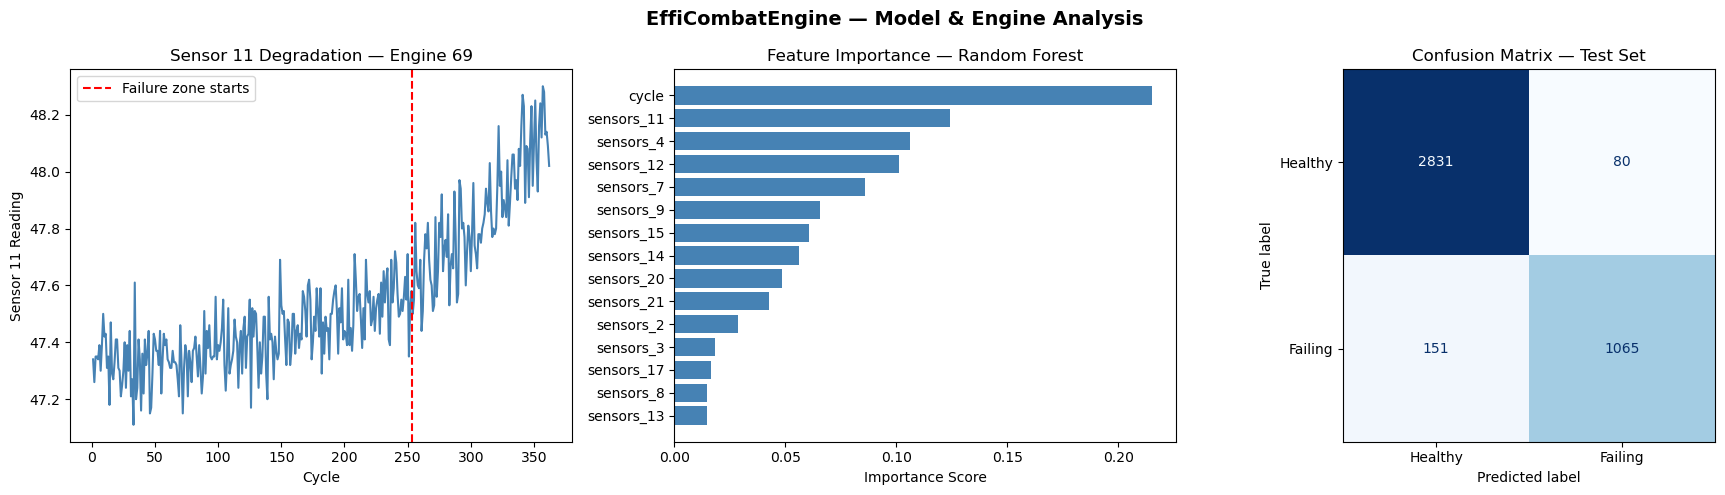

In [28]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('EffiCombatEngine — Model & Engine Analysis', fontsize=14, fontweight='bold')

# 1. Sensor 11 degradation over time for engine 69
engine69 = df[df['engine_id'] == 69]
axes[0].plot(engine69['cycle'], engine69['sensors_11'], color='steelblue', linewidth=1.5)
axes[0].axvline(x=engine69['cycle'].max() * 0.7, color='red', linestyle='--', label='Failure zone starts')
axes[0].set_title('Sensor 11 Degradation — Engine 69')
axes[0].set_xlabel('Cycle')
axes[0].set_ylabel('Sensor 11 Reading')
axes[0].legend()

# 2. Feature importance
importance_sorted = importance.sort_values()
axes[1].barh(importance_sorted.index, importance_sorted.values, color='steelblue')
axes[1].set_title('Feature Importance — Random Forest')
axes[1].set_xlabel('Importance Score')

# 3. Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Healthy', 'Failing'])
disp.plot(ax=axes[2], colorbar=False, cmap='Blues')
axes[2].set_title('Confusion Matrix — Test Set')

plt.tight_layout()
plt.savefig('cell1_model_engine.png', dpi=150, bbox_inches='tight')
plt.show()

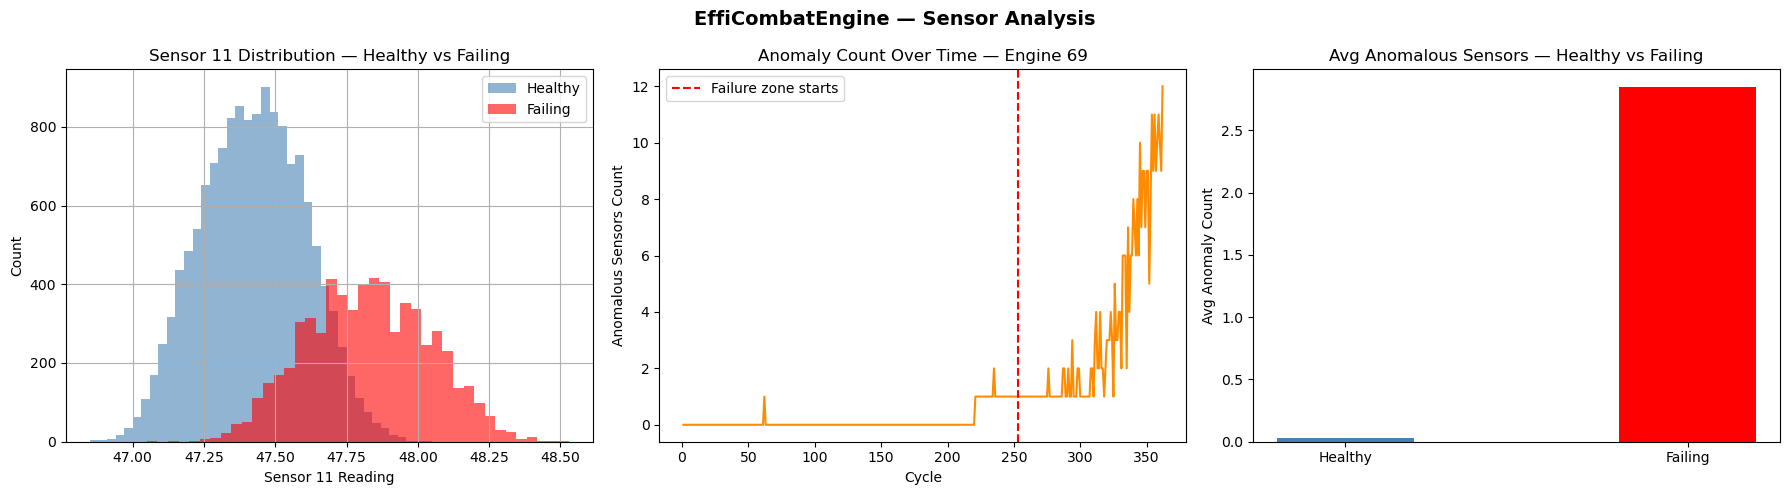

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('EffiCombatEngine — Sensor Analysis', fontsize=14, fontweight='bold')

# 1. Healthy vs Failing — Sensor 11 distribution
df[df['label']==0]['sensors_11'].hist(ax=axes[0], alpha=0.6, color='steelblue', bins=40, label='Healthy')
df[df['label']==1]['sensors_11'].hist(ax=axes[0], alpha=0.6, color='red', bins=40, label='Failing')
axes[0].set_title('Sensor 11 Distribution — Healthy vs Failing')
axes[0].set_xlabel('Sensor 11 Reading')
axes[0].set_ylabel('Count')
axes[0].legend()

# 2. Anomaly count over time — Engine 69
axes[1].plot(engine69['cycle'], engine69['anomaly_count'], color='darkorange', linewidth=1.5)
axes[1].axvline(x=engine69['cycle'].max() * 0.7, color='red', linestyle='--', label='Failure zone starts')
axes[1].set_title('Anomaly Count Over Time — Engine 69')
axes[1].set_xlabel('Cycle')
axes[1].set_ylabel('Anomalous Sensors Count')
axes[1].legend()

# 3. Average anomaly count healthy vs failing
axes[2].bar(['Healthy', 'Failing'],
            df.groupby('label')['anomaly_count'].mean().values,
            color=['steelblue', 'red'], width=0.4)
axes[2].set_title('Avg Anomalous Sensors — Healthy vs Failing')
axes[2].set_ylabel('Avg Anomaly Count')

plt.tight_layout()
plt.savefig('cell2_sensors.png', dpi=150, bbox_inches='tight')
plt.show()

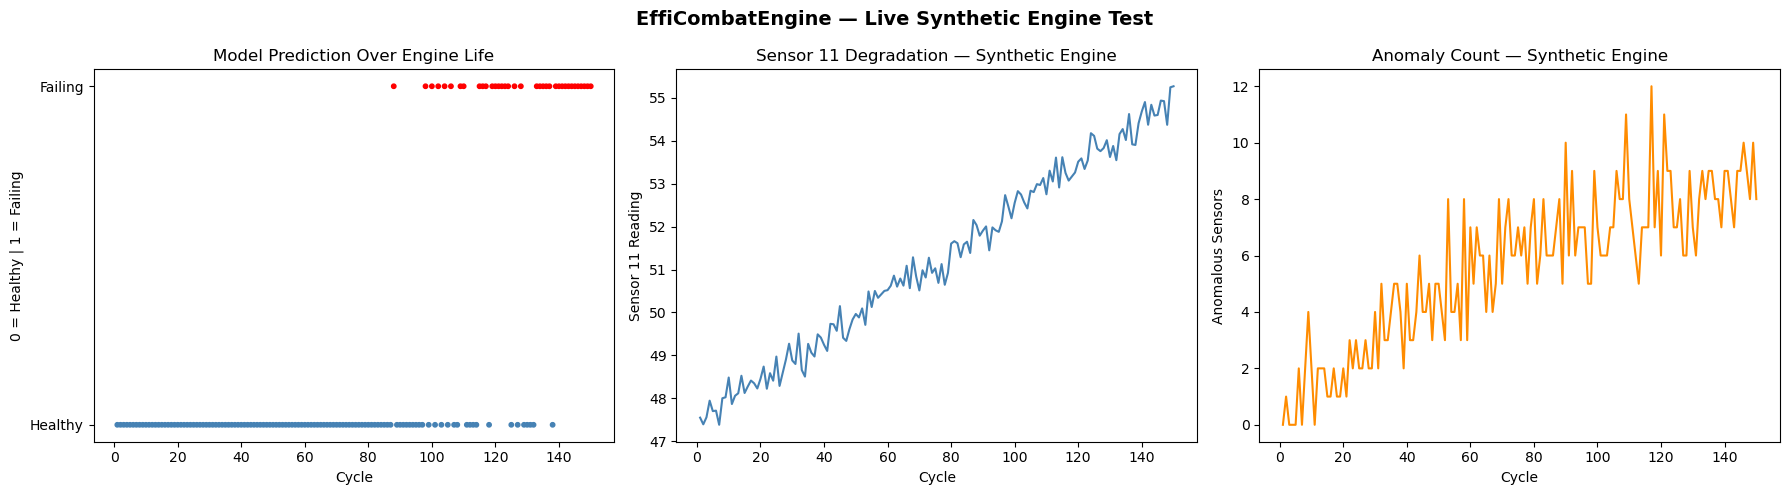


--- Synthetic Engine Summary ---
Total cycles simulated: 150
Cycles predicted Healthy: 114
Cycles predicted Failing: 36
First failure detected at cycle: 88


In [30]:
import numpy as np

# Create synthetic engine — 150 cycles, gradually degrading
np.random.seed(42)
cycles = np.arange(1, 151)

# Simulate gradual sensor degradation as cycles increase
synthetic = pd.DataFrame()
synthetic['cycle'] = cycles
synthetic['sensors_2']  = 642.5  + np.random.normal(0, 0.5, 150) + cycles * 0.01
synthetic['sensors_3']  = 1588.0 + np.random.normal(0, 6, 150)   + cycles * 0.05
synthetic['sensors_4']  = 1405.0 + np.random.normal(0, 9, 150)   + cycles * 0.08
synthetic['sensors_7']  = 553.0  + np.random.normal(0, 0.9, 150) - cycles * 0.02
synthetic['sensors_8']  = 2388.0 + np.random.normal(0, 0.07, 150)
synthetic['sensors_9']  = 9059.0 + np.random.normal(0, 20, 150)  - cycles * 0.5
synthetic['sensors_11'] = 47.4   + np.random.normal(0, 0.27, 150) + cycles * 0.05
synthetic['sensors_12'] = 521.7  + np.random.normal(0, 0.74, 150) + cycles * 0.02
synthetic['sensors_13'] = 2388.0 + np.random.normal(0, 0.07, 150)
synthetic['sensors_14'] = 8139.0 + np.random.normal(0, 19, 150)  + cycles * 0.1
synthetic['sensors_15'] = 8.43   + np.random.normal(0, 0.04, 150) - cycles * 0.001
synthetic['sensors_17'] = 392.6  + np.random.normal(0, 1.5, 150) + cycles * 0.02
synthetic['sensors_20'] = 38.9   + np.random.normal(0, 0.18, 150) - cycles * 0.01
synthetic['sensors_21'] = 23.3   + np.random.normal(0, 0.11, 150) + cycles * 0.008

# Predict cycle by cycle
synthetic['prediction'] = model.predict(synthetic[X.columns])

# Z-score anomaly count
z = (synthetic[X.columns] - sensor_mean) / sensor_std
synthetic['anomaly_count'] = (z.abs() > 3).sum(axis=1)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('EffiCombatEngine — Live Synthetic Engine Test', fontsize=14, fontweight='bold')

# 1. Prediction over time
colors = ['steelblue' if p == 0 else 'red' for p in synthetic['prediction']]
axes[0].scatter(synthetic['cycle'], synthetic['prediction'], c=colors, s=10)
axes[0].set_title('Model Prediction Over Engine Life')
axes[0].set_xlabel('Cycle')
axes[0].set_ylabel('0 = Healthy | 1 = Failing')
axes[0].set_yticks([0, 1])
axes[0].set_yticklabels(['Healthy', 'Failing'])

# 2. Sensor 11 degradation
axes[1].plot(synthetic['cycle'], synthetic['sensors_11'], color='steelblue', linewidth=1.5)
axes[1].set_title('Sensor 11 Degradation — Synthetic Engine')
axes[1].set_xlabel('Cycle')
axes[1].set_ylabel('Sensor 11 Reading')

# 3. Anomaly count over time
axes[2].plot(synthetic['cycle'], synthetic['anomaly_count'], color='darkorange', linewidth=1.5)
axes[2].set_title('Anomaly Count — Synthetic Engine')
axes[2].set_xlabel('Cycle')
axes[2].set_ylabel('Anomalous Sensors')

plt.tight_layout()
plt.savefig('cell3_synthetic.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary
print("\n--- Synthetic Engine Summary ---")
print(f"Total cycles simulated: 150")
print(f"Cycles predicted Healthy: {(synthetic['prediction']==0).sum()}")
print(f"Cycles predicted Failing: {(synthetic['prediction']==1).sum()}")
print(f"First failure detected at cycle: {synthetic[synthetic['prediction']==1]['cycle'].min()}")

In [31]:
total_cycles = 150
threshold = total_cycles * 0.7
print(f"Expected failure zone starts at cycle: {threshold}")
print(f"Model first detected failure at cycle: 88")

Expected failure zone starts at cycle: 105.0
Model first detected failure at cycle: 88


In [32]:
print(f"Total cycles simulated: 150")
print(f"Cycles predicted Healthy: {(synthetic['prediction']==0).sum()}")
print(f"Cycles predicted Failing: {(synthetic['prediction']==1).sum()}")
print(f"First failure detected at cycle: {synthetic[synthetic['prediction']==1]['cycle'].min()}")
print(f"Expected failure zone: cycle {int(total_cycles * 0.7)}")
print(f"Early warning lead time: {int(total_cycles * 0.7) - synthetic[synthetic['prediction']==1]['cycle'].min()} cycles")

Total cycles simulated: 150
Cycles predicted Healthy: 114
Cycles predicted Failing: 36
First failure detected at cycle: 88
Expected failure zone: cycle 105
Early warning lead time: 17 cycles


In [33]:
import pandas as pd
df_fd003 = pd.read_csv('train_FD003.txt', sep=r'\s+', header=None, names=columns)
print(df_fd003.shape)

(24720, 26)


In [34]:
print(df_fd003.columns.tolist())    

['engine_id', 'cycle', 'setting_1', 'setting_2', 'setting_3', 'sensors_1', 'sensors_2', 'sensors_3', 'sensors_4', 'sensors_5', 'sensors_6', 'sensors_7', 'sensors_8', 'sensors_9', 'sensors_10', 'sensors_11', 'sensors_12', 'sensors_13', 'sensors_14', 'sensors_15', 'sensors_16', 'sensors_17', 'sensors_18', 'sensors_19', 'sensors_20', 'sensors_21']


In [35]:
mc = df_fd003.groupby('engine_id')['cycle'].max()
df_fd003['max_cycle'] = df_fd003['engine_id'].map(mc)
df_fd003['RUL'] = df_fd003['max_cycle'] - df_fd003['cycle']
df_fd003['label'] = (df_fd003['RUL'] <= 0.3 * df_fd003['max_cycle']).astype(int)
print(df_fd003['label'].value_counts())

label
0    17250
1     7470
Name: count, dtype: int64


In [36]:
stats = df_fd003.describe().T
low_var = stats[stats['std'] < 0.01].index
df_fd003 = df_fd003.drop(columns=low_var)

meta = ['engine_id', 'max_cycle', 'RUL']
X2 = df_fd003.drop(columns=meta + ['label'])
y2 = df_fd003['label']

print(X2.shape)

(24720, 16)


In [37]:
print(set(X2.columns) - set(X.columns))

{'sensors_6'}


In [38]:
X2 = X2.drop(columns=['sensors_6'])
print(X2.shape)

(24720, 15)


In [39]:
preds = model.predict(X2)
from sklearn.metrics import classification_report
print(classification_report(y2, preds))

              precision    recall  f1-score   support

           0       0.87      0.98      0.92     17250
           1       0.93      0.65      0.76      7470

    accuracy                           0.88     24720
   macro avg       0.90      0.81      0.84     24720
weighted avg       0.89      0.88      0.87     24720



In [40]:
import pickle
with open('efficombat_model.pkl', 'wb') as f:
    pickle.dump(model, f)
print("model saved")

model saved


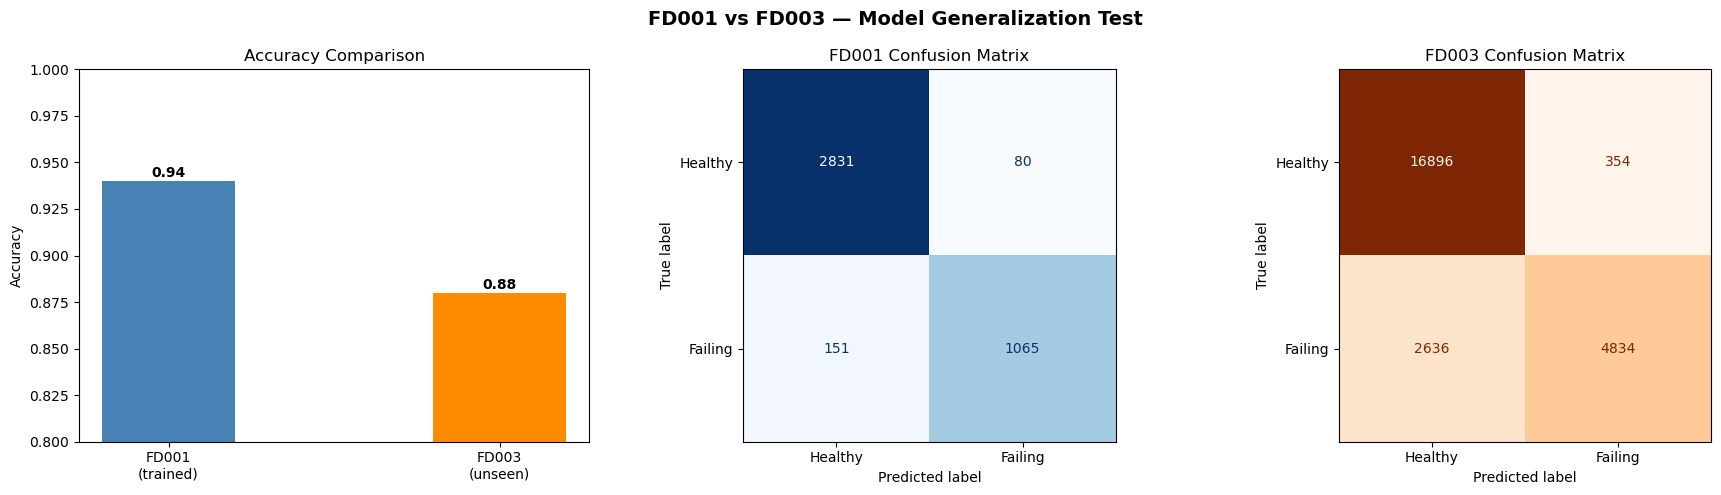

In [42]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('FD001 vs FD003 — Model Generalization Test', fontsize=14, fontweight='bold')

# 1. Accuracy comparison
datasets = ['FD001\n(trained)', 'FD003\n(unseen)']
scores = [0.94, 0.88]
colors = ['steelblue', 'darkorange']
axes[0].bar(datasets, scores, color=colors, width=0.4)
axes[0].set_ylim(0.8, 1.0)
axes[0].set_title('Accuracy Comparison')
axes[0].set_ylabel('Accuracy')
for i, v in enumerate(scores):
    axes[0].text(i, v + 0.002, str(v), ha='center', fontweight='bold')

# 2. Confusion matrix FD001
cm1 = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm1, display_labels=['Healthy', 'Failing']).plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('FD001 Confusion Matrix')

# 3. Confusion matrix FD003
cm2 = confusion_matrix(y2, preds)
ConfusionMatrixDisplay(cm2, display_labels=['Healthy', 'Failing']).plot(ax=axes[2], colorbar=False, cmap='Oranges')
axes[2].set_title('FD003 Confusion Matrix')

plt.tight_layout()
plt.savefig('fd001_vs_fd003.png', dpi=150, bbox_inches='tight')
plt.show()

In [43]:
print(df_fd003['sensors_6'].std())
print(df_fd003.groupby('label')['sensors_6'].mean())

0.018116000048510477
label
0    21.596586
1    21.594122
Name: sensors_6, dtype: float64


In [46]:
from sklearn.ensemble import RandomForestRegressor

Xr = df[X.columns]
yr = df['RUL']

Xr_train = Xr.iloc[:int(len(Xr)*0.8)]
Xr_test = Xr.iloc[int(len(Xr)*0.8):]
yr_train = yr.iloc[:int(len(yr)*0.8)]
yr_test = yr.iloc[int(len(yr)*0.8):]

reg = RandomForestRegressor(n_estimators=100, random_state=42)
reg.fit(Xr_train, yr_train)
print("done")

done


In [50]:
from sklearn.metrics import mean_absolute_error, r2_score

X_test_rul = df_last[X.columns]
yr_pred = reg.predict(X_test_rul)

mae = mean_absolute_error(rul['RUL'], yr_pred)
r2 = r2_score(rul['RUL'], yr_pred)

print(f"MAE: {mae:.2f} cycles")
print(f"R2: {r2:.2f}")

MAE: 19.89 cycles
R2: 0.60


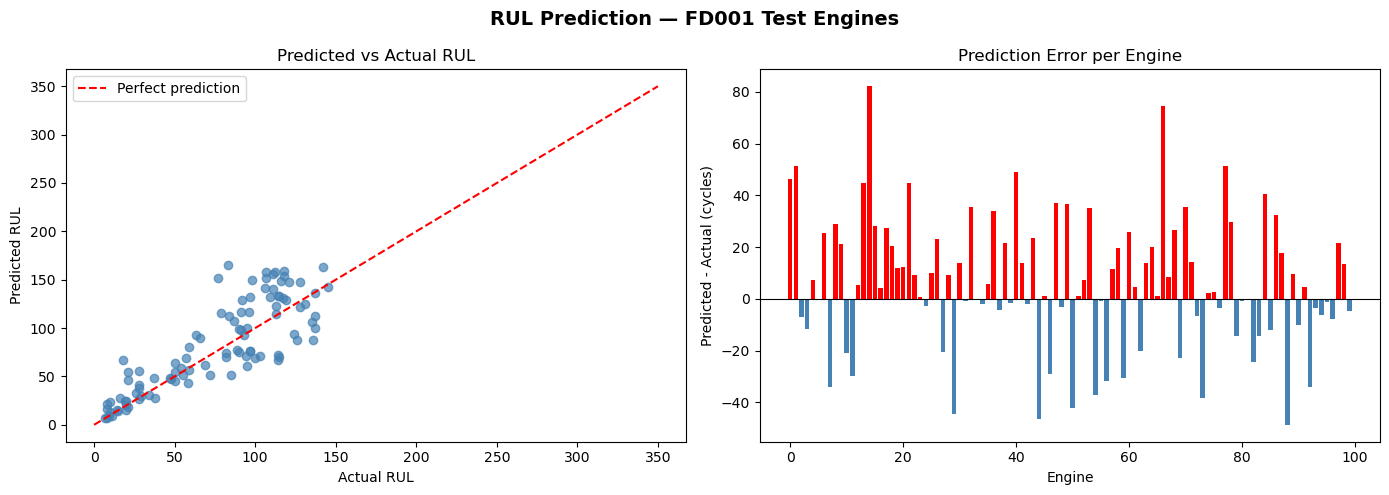

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('RUL Prediction — FD001 Test Engines', fontsize=14, fontweight='bold')

# 1. Predicted vs Actual
axes[0].scatter(rul['RUL'], yr_pred, color='steelblue', alpha=0.7)
axes[0].plot([0, 350], [0, 350], 'r--', label='Perfect prediction')
axes[0].set_title('Predicted vs Actual RUL')
axes[0].set_xlabel('Actual RUL')
axes[0].set_ylabel('Predicted RUL')
axes[0].legend()

# 2. Error per engine
errors = yr_pred - rul['RUL'].values
axes[1].bar(range(100), errors, color=['red' if e > 0 else 'steelblue' for e in errors])
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Prediction Error per Engine')
axes[1].set_xlabel('Engine')
axes[1].set_ylabel('Predicted - Actual (cycles)')

plt.tight_layout()
plt.savefig('rul_prediction.png', dpi=150, bbox_inches='tight')
plt.show()

In [52]:
# Use last 10 cycles average per engine instead of just last cycle
last10 = df_test.groupby('engine_id').tail(10)
X_test_avg = last10.groupby('engine_id')[X.columns.tolist()].mean()

yr_pred2 = reg.predict(X_test_avg)

mae2 = mean_absolute_error(rul['RUL'], yr_pred2)
r2_2 = r2_score(rul['RUL'], yr_pred2)

print(f"MAE: {mae2:.2f} cycles")
print(f"R2: {r2_2:.2f}")

MAE: 20.56 cycles
R2: 0.61


In [54]:
# add anomaly count to features
z = (df[X.columns] - sensor_mean) / sensor_std
df['anomaly_count'] = (z.abs() > 3).sum(axis=1)

Xr3 = df[X.columns.tolist() + ['anomaly_count']]
yr3 = df['RUL']

Xr3_train = Xr3.iloc[:int(len(Xr3)*0.8)]
yr3_train = yr3.iloc[:int(len(yr3)*0.8)]

reg3 = RandomForestRegressor(n_estimators=100, random_state=42)
reg3.fit(Xr3_train, yr3_train)

# add anomaly count to test data too
z_test = (df_last[X.columns] - sensor_mean) / sensor_std
df_last['anomaly_count'] = (z_test.abs() > 3).sum(axis=1)

yr_pred4 = reg3.predict(df_last[X.columns.tolist() + ['anomaly_count']])

mae4 = mean_absolute_error(rul['RUL'], yr_pred4)
r2_4 = r2_score(rul['RUL'], yr_pred4)

print(f"MAE: {mae4:.2f} cycles")
print(f"R2: {r2_4:.2f}")

MAE: 19.70 cycles
R2: 0.59


In [55]:
from xgboost import XGBRegressor

Xr = df[X.columns]
yr = df['RUL']

Xr_train = Xr.iloc[:int(len(Xr)*0.8)]
Xr_test = Xr.iloc[int(len(Xr)*0.8):]
yr_train = yr.iloc[:int(len(yr)*0.8)]
yr_test = yr.iloc[int(len(yr)*0.8):]

xgb = XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
xgb.fit(Xr_train, yr_train)

yr_pred_xgb = xgb.predict(df_last[X.columns])

mae_xgb = mean_absolute_error(rul['RUL'], yr_pred_xgb)
r2_xgb = r2_score(rul['RUL'], yr_pred_xgb)

print(f"MAE: {mae_xgb:.2f} cycles")
print(f"R2: {r2_xgb:.2f}")

MAE: 21.55 cycles
R2: 0.54


In [57]:
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
Xr_train_s = sc.fit_transform(Xr_train)
Xr_test_s = sc.transform(df_last[X.columns])

mlp = MLPRegressor(hidden_layer_sizes=(128, 64), max_iter=500, random_state=42, verbose=False)
mlp.fit(Xr_train_s, yr_train)

yr_pred_mlp = mlp.predict(Xr_test_s)

mae_mlp = mean_absolute_error(rul['RUL'], yr_pred_mlp)
r2_mlp = r2_score(rul['RUL'], yr_pred_mlp)

print(f"MAE: {mae_mlp:.2f} cycles")
print(f"R2: {r2_mlp:.2f}")

MAE: 21.78 cycles
R2: 0.53


In [ ]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler



ready


In [59]:
scaler = MinMaxScaler()
feature_cols = X.columns.tolist()

# scale the data
df_scaled = df.copy()
df_scaled[feature_cols] = scaler.fit_transform(df[feature_cols])

# create sequences
window = 30

def make_sequences(data, window):
    Xs, ys = [], []
    for eng in data['engine_id'].unique():
        eng_data = data[data['engine_id'] == eng]
        vals = eng_data[feature_cols].values
        rul_vals = eng_data['RUL'].values
        for i in range(len(vals) - window):
            Xs.append(vals[i:i+window])
            ys.append(rul_vals[i+window])
    return np.array(Xs), np.array(ys)

Xs, ys = make_sequences(df_scaled, window)
print(Xs.shape, ys.shape)

(17631, 30, 15) (17631,)


In [69]:
from sklearn.model_selection import train_test_split

Xs_train, Xs_test, ys_train, ys_test = train_test_split(Xs, ys, test_size=0.2, random_state=42)

model_lstm = Sequential([
    LSTM(64, input_shape=(window, len(feature_cols)), return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1)
])

model_lstm.compile(optimizer='adam', loss='mae')
es = EarlyStopping(patience=5, restore_best_weights=True)

history = model_lstm.fit(Xs_train, ys_train, 
                          epochs=60, 
                          batch_size=64, 
                          validation_split=0.1,
                          callbacks=[es],
                          verbose=1)
print("done")

Epoch 1/60


/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


199/199 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 87.1701 - val_loss: 78.8744
Epoch 2/60
199/199 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 77.9345 - val_loss: 73.8600
Epoch 3/60
199/199 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 73.7952 - val_loss: 69.5627
Epoch 4/60
199/199 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 69.6866 - val_loss: 65.8939
Epoch 5/60
199/199 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 64.9736 - val_loss: 62.8712
Epoch 6/60
199/199 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 62.6286 - val_loss: 60.3099
Epoch 7/60
199/199 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 60.1924 - val_loss: 58.1218
Epoch 8/60
199/199 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 57.5517 - val_loss: 56.3303
Epoch 9/60
199/199 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 56.4948 - val_loss: 54.8659
Epoch 10/60
199/199 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 54.4447 - val_loss: 53.6632
Epoch 11/60
199/199 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 54.0450 - val_loss: 52.7489
Epoch 12/60
199/199 ━━━━━━━━━━

In [73]:
# scale test data
df_test_scaled = df_test.copy()
df_test_scaled[feature_cols] = scaler.transform(df_test[feature_cols])

# get last 30 cycles per engine
def get_last_sequence(data, window):
    Xs = []
    for eng in data['engine_id'].unique():
        eng_data = data[data['engine_id'] == eng]
        vals = eng_data[feature_cols].values
        if len(vals) >= window:
            Xs.append(vals[-window:])
        else:
            # pad with zeros if engine has less than 30 cycles
            pad = np.zeros((window - len(vals), len(feature_cols)))
            Xs.append(np.vstack([pad, vals]))
    return np.array(Xs)

X_lstm_test = get_last_sequence(df_test_scaled, window)
yr_pred_lstm = model_lstm.predict(X_lstm_test).flatten()

mae_lstm = mean_absolute_error(rul['RUL'], yr_pred_lstm)
r2_lstm = r2_score(rul['RUL'], yr_pred_lstm)

print(f"MAE: {mae_lstm:.2f} cycles")
print(f"R2: {r2_lstm:.2f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
MAE: 13.67 cycles
R2: 0.79


In [71]:
model_lstm.save('efficombat_lstm.keras')
print("lstm saved")

lstm saved


In [72]:
# predict RUL for each engine and compare with ground truth
results = pd.DataFrame()
results['engine_id'] = df_test['engine_id'].unique()
results['actual_RUL'] = rul['RUL'].values
results['predicted_RUL'] = yr_pred_lstm
results['error'] = abs(results['actual_RUL'] - results['predicted_RUL']).round(1)

print(results.head(10))

   engine_id  actual_RUL  predicted_RUL  error
0          1         112     158.184372   46.2
1          2          98     149.798126   51.8
2          3          69      45.655941   23.3
3          4          82      71.214745   10.8
4          5          91     100.827522    9.8
5          6          93     102.087311    9.1
6          7          91     110.293289   19.3
7          8          95      83.465218   11.5
8          9         111     149.632263   38.6
9         10          96      92.465843    3.5


In [74]:
print(f"Mean Error: {results['error'].mean():.2f} cycles")
print(f"Best prediction: engine {results.loc[results['error'].idxmin(), 'engine_id']} — error {results['error'].min():.1f} cycles")
print(f"Worst prediction: engine {results.loc[results['error'].idxmax(), 'engine_id']} — error {results['error'].max():.1f} cycles")
print(results.describe())

Mean Error: 13.66 cycles
Best prediction: engine 43 — error 0.4 cycles
Worst prediction: engine 67 — error 58.4 cycles
        engine_id  actual_RUL  predicted_RUL       error
count  100.000000   100.00000     100.000000  100.000000
mean    50.500000    75.52000      78.409363   13.662000
std     29.011492    41.76497      48.265095   13.107294
min      1.000000     7.00000       3.536500    0.400000
25%     25.750000    32.75000      26.231120    3.750000
50%     50.500000    86.00000      87.344124    9.600000
75%     75.250000   112.25000     110.854509   18.400000
max    100.000000   145.00000     158.645874   58.400000


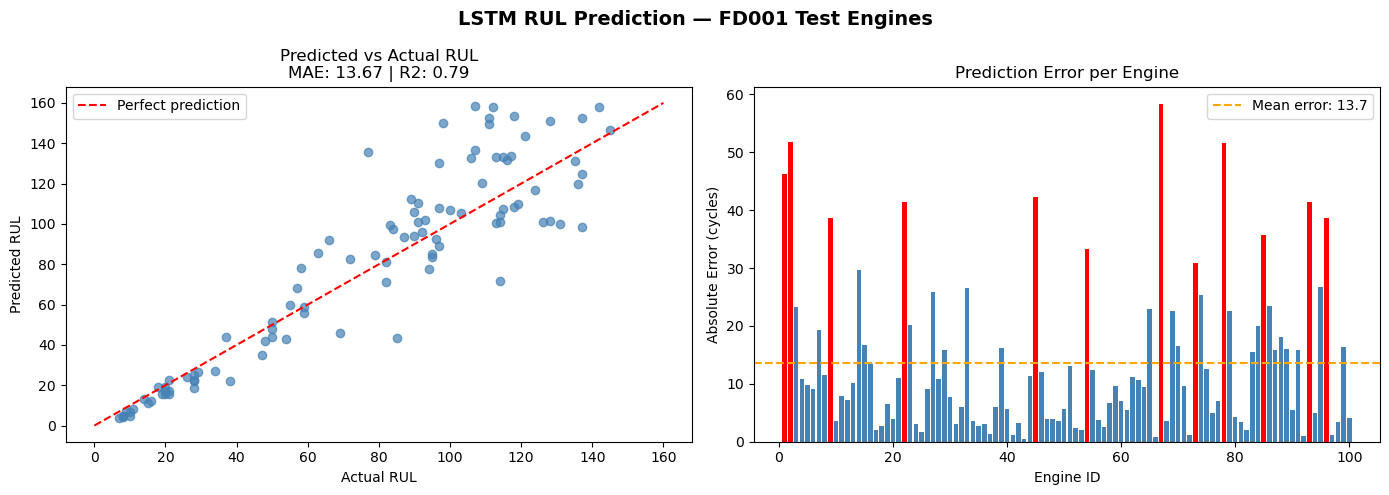

In [75]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('LSTM RUL Prediction — FD001 Test Engines', fontsize=14, fontweight='bold')

# 1. Predicted vs Actual
axes[0].scatter(results['actual_RUL'], results['predicted_RUL'], color='steelblue', alpha=0.7)
axes[0].plot([0, 160], [0, 160], 'r--', label='Perfect prediction')
axes[0].set_title(f'Predicted vs Actual RUL\nMAE: 13.67 | R2: 0.79')
axes[0].set_xlabel('Actual RUL')
axes[0].set_ylabel('Predicted RUL')
axes[0].legend()

# 2. Error per engine
axes[1].bar(results['engine_id'], results['error'], 
            color=['red' if e > 30 else 'steelblue' for e in results['error']])
axes[1].axhline(results['error'].mean(), color='orange', linestyle='--', label=f'Mean error: {results["error"].mean():.1f}')
axes[1].set_title('Prediction Error per Engine')
axes[1].set_xlabel('Engine ID')
axes[1].set_ylabel('Absolute Error (cycles)')
axes[1].legend()

plt.tight_layout()
plt.savefig('lstm_rul.png', dpi=150, bbox_inches='tight')
plt.show()